In [1]:
# Import packages
import numpy as np
import time
from datetime import datetime
import json
import random


import torch
import torch.nn as nn
import torch.optim as optim

from torch_geometric.data import HeteroData
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import global_mean_pool, global_max_pool

from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

from tqdm import tqdm
import sys
from pyg_dataset import NetlistDataset

sys.path.append("models/layers/")
from models.model_att import GNN_node

import lightgbm as lgb
from sklearn.metrics import mean_squared_error
# import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle
import pandas as pd

In [2]:
# Get hyperparameters from config file
with open('config.json', 'r') as fh:
    params = json.load(fh)
    test = params['test'] # if only test but not train
    restart = params['restart'] # if restart training
    reload_dataset = params['reload_dataset'] # if reload already processed h_dataset

    if test:
        restart = True

    prediction = params['prediction'] # one of ['congestion', 'demand']
    model_type = params['model_type'] #this can be one of ["dehnn", "dehnn_att", "digcn", "digat"] "dehnn_att" might need large memory usage
    num_layer = params['num_layer'] #large number will cause OOM
    num_dim = params['num_dim'] #large number will cause OOM
    vn = params['vn'] #use virtual node or not
    trans = params['trans'] #use transformer or not
    aggr = params['aggr'] #use aggregation as one of ["add", "max"]
    device = params['device'] #use cuda or cpu
    learning_rate = params['learning_rate'] #rate of gradient descent
    num_epochs = params['num_epochs'] #length of training

reload_dataset = True
if not reload_dataset:
    # open data files
    dataset = NetlistDataset(data_dir="../data/superblue", load_pd = True, load_pe = True, pl = True, processed = reload_dataset, load_indices=None)
    h_dataset = []
    for data in tqdm(dataset):
        # read in node and net features
        num_instances = data.node_features.shape[0]
        data.num_instances = num_instances
        data.edge_index_sink_to_net[1] = data.edge_index_sink_to_net[1] - num_instances
        data.edge_index_source_to_net[1] = data.edge_index_source_to_net[1] - num_instances
        
        out_degrees = data.net_features[:, 0]
        mask = (out_degrees < 3000)
        mask_edges = mask[data.edge_index_source_to_net[1]] 
        filtered_edge_index_source_to_net = data.edge_index_source_to_net[:, mask_edges]
        data.edge_index_source_to_net = filtered_edge_index_source_to_net

        mask_edges = mask[data.edge_index_sink_to_net[1]] 
        filtered_edge_index_sink_to_net = data.edge_index_sink_to_net[:, mask_edges]
        data.edge_index_sink_to_net = filtered_edge_index_sink_to_net

        h_data = HeteroData()
        h_data['node'].x = data.node_features
        h_data['net'].x = data.net_features.float()
        print(data.node_features.shape)

        # Create hypergraph structure
        edge_index = torch.concat([data.edge_index_sink_to_net, data.edge_index_source_to_net], dim=1)
        h_data['node', 'to', 'net'].edge_index, h_data['node', 'to', 'net'].edge_weight = gcn_norm(edge_index, add_self_loops=False)
        h_data['node', 'to', 'net'].edge_type = torch.concat([torch.zeros(data.edge_index_sink_to_net.shape[1]), torch.ones(data.edge_index_source_to_net.shape[1])]).bool()
        h_data['net', 'to', 'node'].edge_index, h_data['net', 'to', 'node'].edge_weight = gcn_norm(edge_index.flip(0), add_self_loops=False)
        
        h_data['design_name'] = data['design_name']
        h_data.num_instances = data.node_features.shape[0]
        variant_data_lst = []

        # Read congestion targets for prediction
        node_congestion = data.node_congestion.long()
        net_congestion = data.net_congestion.long()
        node_demand = data.node_demand.float()
        net_demand = data.net_demand.float()
        # node_demand = (node_demand - torch.mean(node_demand)) / torch.std(node_demand)
        # net_demand = (net_demand - torch.mean(net_demand))/ torch.std(net_demand)
        
        # Create and save processed data
        batch = data.batch
        num_vn = len(np.unique(batch))
        vn_node = torch.concat([global_mean_pool(h_data['node'].x, batch), 
                global_max_pool(h_data['node'].x, batch)], dim=1)

        variant_data_lst.append((node_demand, net_demand, node_congestion, net_congestion, batch, num_vn, vn_node, data.mask)) 
        h_data['variant_data_lst'] = variant_data_lst
        h_dataset.append(h_data)
        
    torch.save(h_dataset, "h_dataset.pt")
    
else:
    dataset = torch.load("h_dataset.pt")
    h_dataset = []
    for data in dataset:
        h_dataset.append(data)
    
sys.path.append("models/layers/")

C:\Users\rebal\AppData\Local\Temp\ipykernel_29164\1620237413.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load("h_dataset.pt")


In [3]:
load_data_indices = [idx for idx in range(len(h_dataset))]
all_train_indices = load_data_indices[:4] + load_data_indices[6:]
all_valid_indices = load_data_indices[4:5]
all_test_indices = load_data_indices[5:6]

In [4]:
X_train_list = []
y_train_list_r = []
X_test_list = []
y_test_list_r = []
train_idx = all_train_indices
test_idx = all_test_indices
for i in train_idx:
    X_train_list.append(h_dataset[i]["net"]["x"])
    y_train_list_r.append(h_dataset[i]["variant_data_lst"][0][1])
for i in test_idx:
    X_test_list.append(h_dataset[i]["net"]["x"])
    y_test_list_r.append(h_dataset[i]["variant_data_lst"][0][1])        

In [5]:
X_train = torch.cat(X_train_list, dim=0).numpy()
y_train_reg = torch.cat(y_train_list_r, dim=0).numpy()
X_test = torch.cat(X_test_list, dim=0).numpy()
y_test_reg = torch.cat(y_test_list_r, dim=0).numpy()

In [12]:
X_train = X_train[:, :-1]
X_test = X_test[:, :-1]

In [13]:
train_data = lgb.Dataset(X_train, label=y_train_reg)
valid_data = lgb.Dataset(X_test, label=y_test_reg)

In [14]:
start = time.time()
params = {
    "objective": "regression",
    "metric": "rmse",  # Root Mean Squared Error
    "boosting_type": "gbdt",  # Gradient Boosting Decision Tree
    "learning_rate": 0.1,
    "num_leaves": 31,  # Controls tree complexity
    "max_depth": 6,  # No depth limit
    "feature_fraction": 1,  # Randomly select 80% of features per tree
    "bagging_fraction": 0.8,  # Randomly select 80% of data per tree
    "bagging_freq": 5,  # Perform bagging every 5 iterations
    "verbose": -1,
}
model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=500,  # Max trees
)
print(time.time()-start)

75.98521518707275


In [15]:
y_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred))
print(f"Train MSE: {rmse}")

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
print(f"Validation MSE: {rmse}")



Train MSE: 10.924287692518643
Validation MSE: 15.775064576339032


Train MSE: 9.46204727397002
Validation MSE: 7.620669121305325

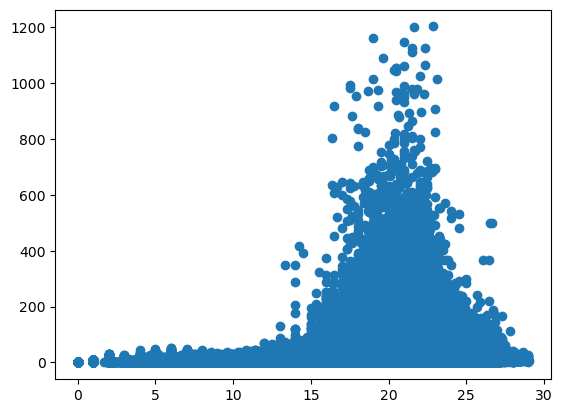

In [12]:
plt.scatter(X_train[:,11], y_train_reg)

In [13]:
pearsonr(X_train[:,11], y_train_reg)

PearsonRResult(statistic=0.2305936347398955, pvalue=0.0)

In [14]:
file_name = '../data/superblue/superblue_19/net_demand_capacity.pkl'
f = open(file_name, 'rb')
net_demand_dictionary = pickle.load(f)
f.close()

In [15]:
demand_cap = pd.DataFrame(net_demand_dictionary)

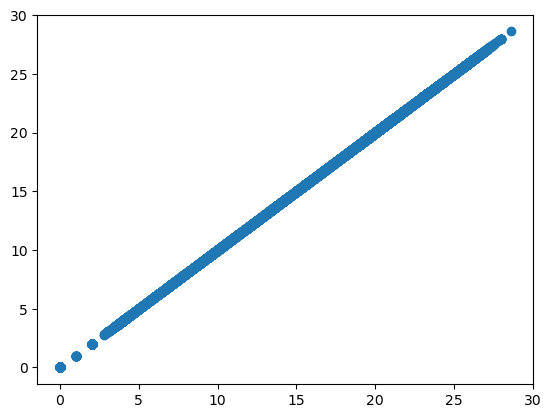

In [16]:
plt.scatter(X_train[:,11][:len(demand_cap["capacity"])], demand_cap["capacity"])

In [17]:
y_test_reg.std()

8.0087